<a href="https://colab.research.google.com/github/Madziurek/PUM23/blob/regresja/PUM5_regresjanieliniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

<ipython-input-34-9f69f8392d9a>:9: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(


First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [ ]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

In [ ]:
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])

df['Education Level'] = label_encoder.fit_transform(df['Education Level'])

df['Job Title'] = label_encoder.fit_transform(df['Job Title'])


In [ ]:
for column in df.columns:
  df[column].fillna(df[column].mean(), inplace=True)

<ipython-input-37-69eacf26a006>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


Zbuduj model benchmarkowy - zwykłą regresję liniową

In [ ]:
X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"]= [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]


print(vif_data)

                  feature        VIF
0                     Age  20.096027
1                  Gender   2.063624
2         Education Level   2.330367
3               Job Title   6.568690
4     Years of Experience  92.382590
5  YearsExperienceSquared  40.949484


Spróbuj poprawić wynik używając regresji LASSO

In [ ]:
lasso_model = Lasso(alpha=1.0, fit_intercept=True, precompute=False, copy_X=True, max_iter=1000, tol=0.0001, warm_start=False, positive=False, random_state=None, selection='cyclic')

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("LASSO Regression Metrics:")
print("MSE:", mse_lasso)
print("MAE:", mae_lasso)
print("R-squared:", r2_lasso)

LASSO Regression Metrics:
MSE: 251749400.53547803
MAE: 10871.465798047679
R-squared: 0.88195939484269


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


In [ ]:
df['YearsExperienceSquared'] = df['Years of Experience'] ** 2

X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lasso_model = Lasso(alpha=1.0, fit_intercept=True, precompute=False, copy_X=True, max_iter=1000, tol=0.0001, warm_start=False, positive=False, random_state=None, selection='cyclic')
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("LASSO Regression Metrics (with YearsExperienceSquared):")
print("MSE:", mse_lasso)
print("MAE:", mae_lasso)
print("R-squared:", r2_lasso)


LASSO Regression Metrics (with YearsExperienceSquared):
MSE: 251749400.53547803
MAE: 10871.465798047679
R-squared: 0.88195939484269


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

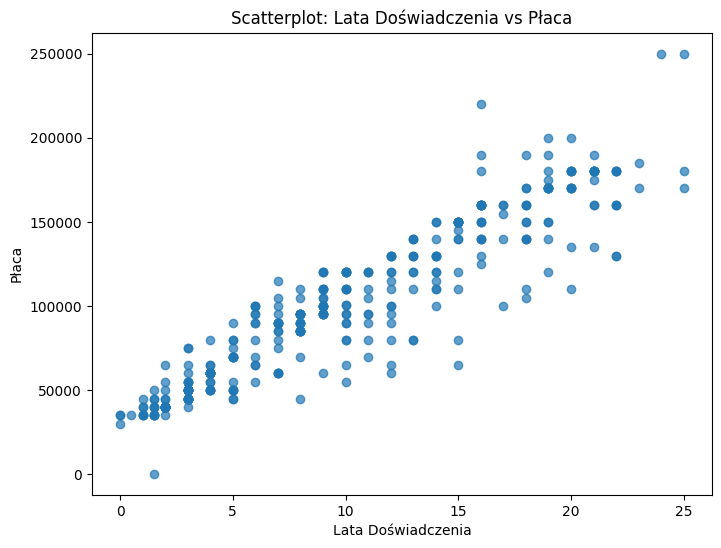

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(8, 6))
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.7)
plt.xlabel('Lata Doświadczenia')
plt.ylabel('Płaca')
plt.title('Scatterplot: Lata Doświadczenia vs Płaca')
plt.show()

Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

In [ ]:
from sklearn import neighbors

knn_regressor = neighbors.KNeighborsRegressor(n_neighbors=7)
knn_regressor.fit(X_train, y_train)
y_pred_knn = knn_regressor.predict(X_test)

mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("LASSO Regression Metrics (with YearsExperienceSquared):")
print("MSE:", mse_knn)
print("MAE:", mae_knn)
print("R-squared:", r2_knn)

LASSO Regression Metrics (with YearsExperienceSquared):
MSE: 292832996.35326475
MAE: 11574.128855793899
R-squared: 0.8626960619328409


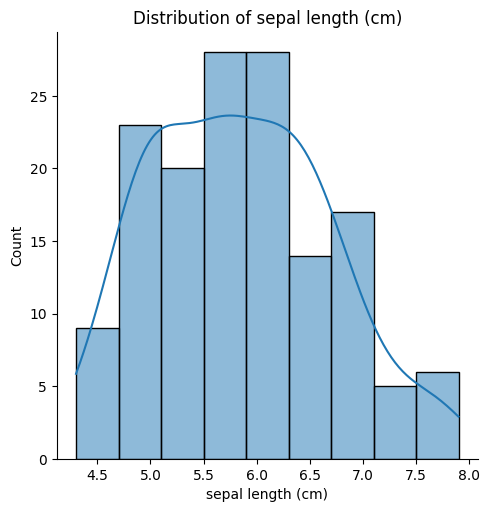

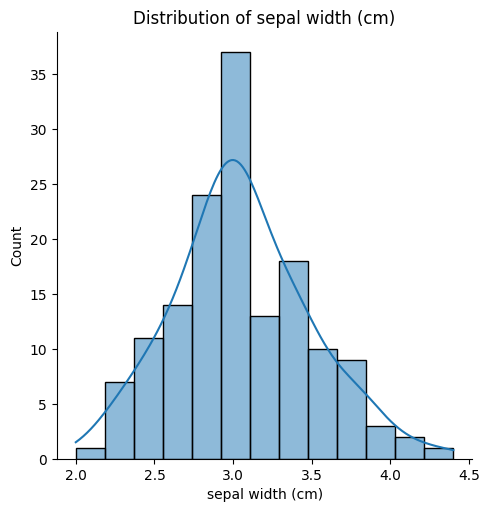

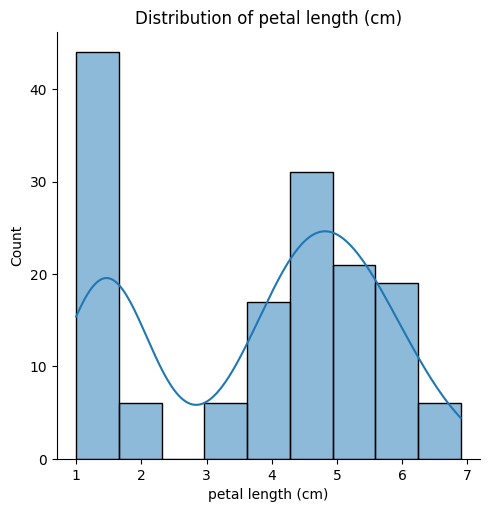

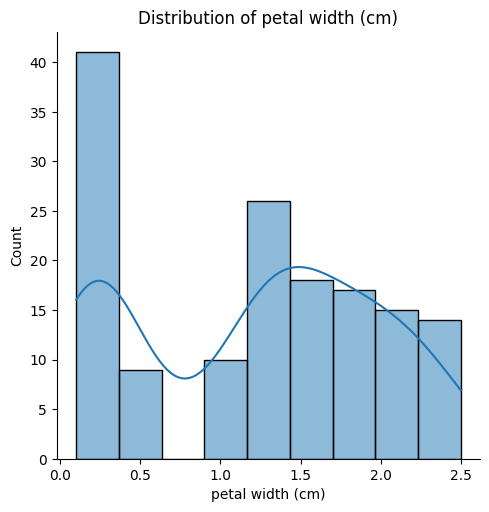

In [16]:
from sklearn import datasets
data = datasets.load_iris()
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.DataFrame(data.data,columns=data.feature_names)
df['target'] = data.target
df.head()

for feature in df.columns[:-1]:
    sns.displot(df, x=feature, kind="hist", kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

#sklearn.ensemble.RandomForestClassifier
#sklearn.tree.DecisionTreeClassifier

In [41]:
def entropia(y):
  if len(y) <= 1:
    return 0
  unique, counts = np.unique(y, return_counts=True)
  probabilities = counts / len(y)
  entropy = -np.sum(probabilities * np.log2(probabilities))
  return entropy

  print(entropia(df['target']))

oryginalna = entropia(df['target'])

print("Entropia oryginalna", oryginalna)

podzial15 = df[df['petal width (cm)'] <= 1.5]['target']
ponad15 = df[df['petal width (cm)'] > 1.5]['target']

Entropia15 = (len(podzial15) / len(df)) * entropia(podzial15) + (len(ponad15) / len(df)) * entropia(ponad15)

podzial38 = df[df['petal width (cm)'] <= 0.38]['target']
ponad38 = df[df['petal width (cm)'] > 0.38]['target']

Entropia38 = (len(podzial38) / len(df)) * entropia(podzial38) + (len(ponad38) / len(df)) * entropia(ponad38)

print("Entropy for split at 1.5:", Entropia15)
print("Entropy for split at 0.38:", Entropia38)
print("Gain for split at 1.5:", oryginalna - Entropia15)
print("Gain for split at 0.38:", oryginalna - Entropia38)

Entropia oryginalna 1.584962500721156
Entropy for split at 1.5: 0.9193868482507093
Entropy for split at 0.38: 0.9654476494015447
Gain for split at 1.5: 0.6655756524704468
Gain for split at 0.38: 0.6195148513196114


In [39]:
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

decision_tree = DecisionTreeClassifier(random_state=42,criterion='entropy')
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

random_forest = RandomForestClassifier(n_estimators=15, random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Decision Tree Accuracy:", accuracy_dt)
print("Random Forest Accuracy:", accuracy_rf)

Decision Tree Accuracy: 0.9777777777777777
Random Forest Accuracy: 1.0
